Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Load Datasets

In [2]:
df1 = pd.read_csv("C:/Users/Chetan/ML Project/CodAlpha Internship Project/Unemployment Analysis with Python/Unemployment in India.csv")
df2 = pd.read_csv("C:/Users/Chetan/ML Project/CodAlpha Internship Project/Unemployment Analysis with Python/Unemployment_Rate_upto_11_2020.csv")

In [3]:
df1

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df2

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.740
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.740
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.740
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.740
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.740
...,...,...,...,...,...,...,...,...,...
262,West Bengal,30-06-2020,M,7.29,30726310,40.39,East,22.9868,87.855
263,West Bengal,31-07-2020,M,6.83,35372506,46.17,East,22.9868,87.855
264,West Bengal,31-08-2020,M,14.87,33298644,47.48,East,22.9868,87.855
265,West Bengal,30-09-2020,M,9.35,35707239,47.73,East,22.9868,87.855


Clean column names

In [5]:
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

Convert Date

In [6]:
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst = True, errors = 'coerce')
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst = True, errors = 'coerce')

Merge

In [7]:
df = pd.concat([df1, df2], ignore_index = True)

Drop missing

In [8]:
df = df.dropna(subset = ['Date', 'Estimated Unemployment Rate (%)'])

Rename

In [9]:
df.rename(columns = {'Estimated Unemployment Rate (%)': 'Unemployment Rate'}, inplace = True)

print("Data Loaded Successfully!")

Data Loaded Successfully!


Trend 

In [10]:
trend = df.groupby('Date')['Unemployment Rate'].mean()

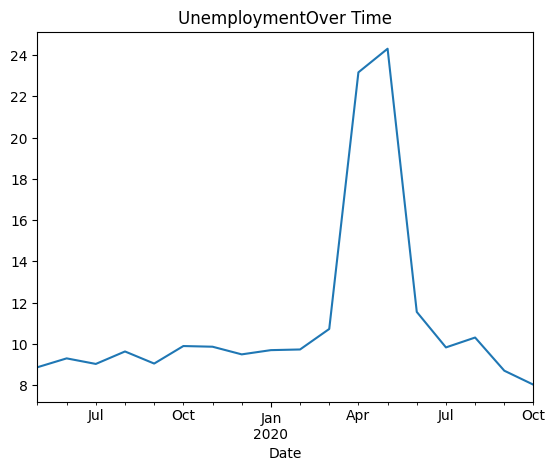

In [11]:
plt.figure()
trend.plot()
plt.title("UnemploymentOver Time")
plt.show()

COVID Impact

In [12]:
covid = df[df['Date'] >= '2020-03-01']
pre = df[df['Date'] < '2020-03-01']

print("pre-COVID:", pre ['Unemployment Rate'].mean())
print("COVID:", covid['Unemployment Rate'].mean())

pre-COVID: 9.484931972789116
COVID: 15.305966587112172


Region

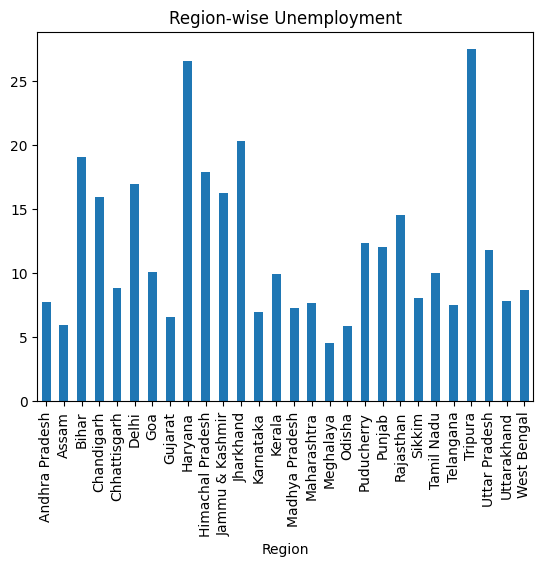

In [13]:
region = df.groupby('Region')['Unemployment Rate'].mean()

plt.figure()
region.plot(kind = 'bar')
plt.title('Region-wise Unemployment')
plt.xticks(rotation = 90)
plt.show()

Monthly

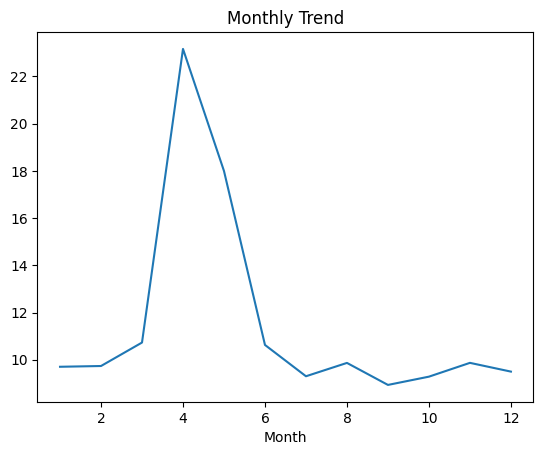

In [14]:
df['Month'] = df['Date'].dt.month

month = df.groupby('Month')['Unemployment Rate'].mean()

plt.figure()
month.plot()
plt.title("Monthly Trend")
plt.show()

Save the File 

In [15]:
df.to_csv("cleaned_data.csv", index = False)

print("Project Completed ✅")

Project Completed ✅
